# Does "anchored VWAP" act like a price magnet? 🧲
### One of the most-shared intraday tricks on trading Twitter — tested on real 5-minute tape, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Price_magnet%3F: Not_supported](https://img.shields.io/badge/Price_magnet%3F-Not_supported-8b949e?style=flat-square)

Here's the pitch you've seen a hundred times in a chart screenshot: drop a special line called an **anchored VWAP** (the volume-weighted average price, started from some *important* moment — the open, a big spike, an earnings gap) and watch how price **"respects"** it. It supposedly acts like a **magnet**: price drifts back to the line, bounces off it, treats it as support and resistance. Anchor it right and you've got a decision line to trade around.

It's a *gorgeous* idea — and the screenshots always look convincing, because **any** average line will sit in the middle of the price and get touched a lot. The real question isn't "does price come back to the line?" (of course it does — it's an average). It's: **when price touches the line, does anything special happen next — more than at a line drawn at random?**

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the random-level placebo and the spread math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Yahoo only serves about **60 days** of 5-minute bars, so this is a *short* window (~59 sessions) on the **most liquid** US tape (SPY/QQQ/AAPL/MSFT/NVDA) — the friendliest possible ground. If a magnet can't survive *here*, it survives nowhere. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from anchored_vwap import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    BARS = data.load_real_complete()
    NS = st.session_avwap(BARS["SPY"])["sess"].nunique()
else:
    BARS = None; NS = 0
print("real AVWAP cache present:", HAVE_REAL, "| tickers:",
      (0 if BARS is None else len(BARS)), "| complete sessions:", NS)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2026-03-30', 'end': '2026-06-23', 'sessions': 59, 'n_tickers': 5, 'bars_per_ticker': 4602, 'fingerprint': '36705730ed53', 'basket': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA'], 'h1': (1, 1682, 0.39, 0.3, 0.89, 0.21, 50, -1.61), 'h3': (3, 1662, 0.25, 0.49, 0.45, -0.33, 51, -1.75), 'h6': (6, 1619, 0.19, 0.35, 0.29, -0.16, 50, -1.81), 'h12': (12, 1545, 0.41, 0.95, 0.5, -0.36, 51, -1.59), 't_one6': 0.19, 'p_placebo6': 0.711, 'cost': [(0.5, 0.19, -0.81), (1.0, 0.19, -1.81), (2.0, 0.19, -3.81)], 'per_ticker': [('SPY', 358, 0.81, 1.16), ('QQQ', 316, 0.8, 0.7), ('AAPL', 320, -0.62, -0.46), ('MSFT', 295, -1.22, -0.69), ('NVDA', 330, 0.97, 0.46)], 'syn': [(0.0, 488, 1.04, 1.03, 1.46, 54), (0.1, 745, 2.23, 3.39, 4.68, 56)]}


real AVWAP cache present: True | tickers: 5 | complete sessions: 59


## The answer first

| Question | Answer |
|---|---|
| When price touches the anchored VWAP, does it bounce ("respect" the level)? | **Barely / no.** The average reaction over the next half-hour is **+0.19 basis points** — that's **+0.0019%**, basically zero. The coin lands heads **50%** of the time. |
| Is the AVWAP line any more special than a line drawn at **random**? | **No.** A random horizontal level reacts **at least as strongly 71%** of the time. The line isn't a magnet — it's just *an average*, and an average gets touched a lot. |
| Can I trade it? | **No.** Even the tiny gross reaction is **eaten by the spread**: net of a 1-bp half-spread on both legs you **lose ~1.8 bp per touch**. Intraday levels die to the bid-ask. |

> The screenshots are real, but they're survivorship in disguise: you remember the touches that bounced and forget the ones that sailed straight through. On the tape, the magnet isn't there.

## 1 · The claim

> *"Anchor your VWAP to a meaningful event — the session open, a high-volume reversal bar, an earnings gap — and that line becomes the level the whole market is watching. Price gets pulled back to it like a magnet, and it acts as support and resistance you can trade against. Buy the bounce off the AVWAP, fade the rejection."*

Anchored VWAP was popularised by **Brian Shannon** (*Maximum Trading Gains with Anchored VWAP*, 2022) and is now a staple of intraday charting — it's a button in every modern platform. The believers' version is strong: the AVWAP isn't just an average, it's a *reference price* that informed traders defend, so it has real gravitational pull.

## 2 · So what?

If the AVWAP really were a magnet, it would be one of the cleanest intraday edges going: a line you can draw in advance, a clear entry (the touch) and a clear bet (it bounces). You'd fade rejections and buy bounces all day.

But two traps hide here. **(1) Everything touches an average.** The AVWAP sits in the middle of the day's price, so price crosses it constantly — of *course* you can find screenshots of clean bounces. The honest test compares the AVWAP to a line drawn at **random** in the same range. **(2) Intraday moves are tiny.** A few basis points of reaction is nothing once you pay the **bid-ask spread** twice. We'll test both.

## 3 · How would we even know?

We take the **5 most liquid** US names (**SPY, QQQ, AAPL, MSFT, NVDA**) and pull every **5-minute bar** for ~**59 trading days** (2026-03-30 → 2026-06-23). For each session:

1. **Draw the line.** Compute the anchored VWAP from the **09:30 open** — the cleanest, most-watched anchor (no cherry-picking which spike to anchor to).
2. **Find the touches.** Every bar where price **crosses** the AVWAP line is an event.
3. **Measure what happens next.** After each touch (entering on the *next* bar, no cheating), does price **revert** back through the line (a bounce = the magnet) or **continue** through it? We orient the number so **positive = the level was respected**.
4. **Compare to random.** Run the exact same test at **randomly placed** horizontal levels. If AVWAP is special, it must beat the random lines. **If it doesn't, the magnet is a mirage.**

## 4 · The teardown — let's actually look

**First, the magnet itself.** Here's the average post-touch reaction at four horizons (1, 3, 6, 12 bars = 5 to 60 minutes after the touch). Positive bars = price respects the level (bounces); zero = nothing happens. Watch how close to zero they are.

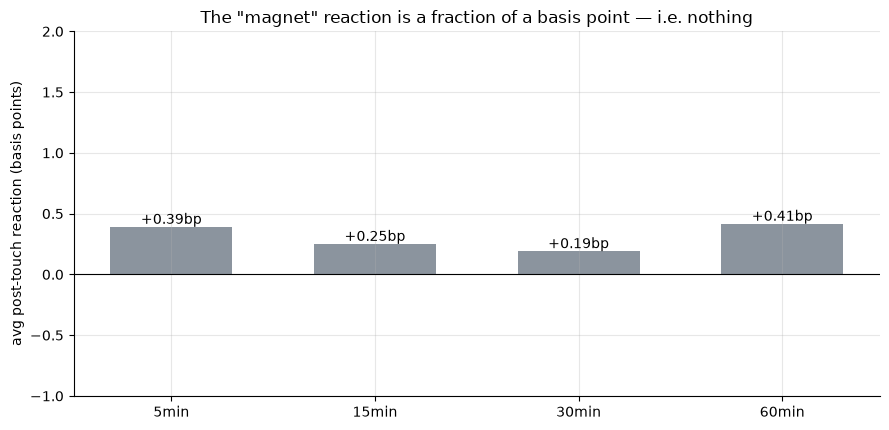

post-touch reaction by horizon (bp): [0.39, 0.25, 0.19, 0.41]


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    av = [st.run_experiment(BARS, horizon=h)['avwap_mean']*1e4 for h in hs]
else:
    av = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar([f'{h*5}min' for h in hs], av, color=GREY, width=.6)
for i,v in enumerate(av): ax.annotate(f'{v:+.2f}bp',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg post-touch reaction (basis points)')
ax.set_title('The "magnet" reaction is a fraction of a basis point — i.e. nothing')
ax.set_ylim(-1, 2)
plt.tight_layout(); plt.show()
print('post-touch reaction by horizon (bp):', [round(v,2) for v in av])

There's the first tell. The reaction tops out at **+0.41 basis points** — you'd need a microscope. A basis point is **0.01%**. Whatever the AVWAP touch is doing, it isn't moving price.

**Now the decisive test.** Is the AVWAP line any more special than a line drawn at **random**? We run the identical bounce test at the AVWAP vs at random horizontal levels in the same price range.

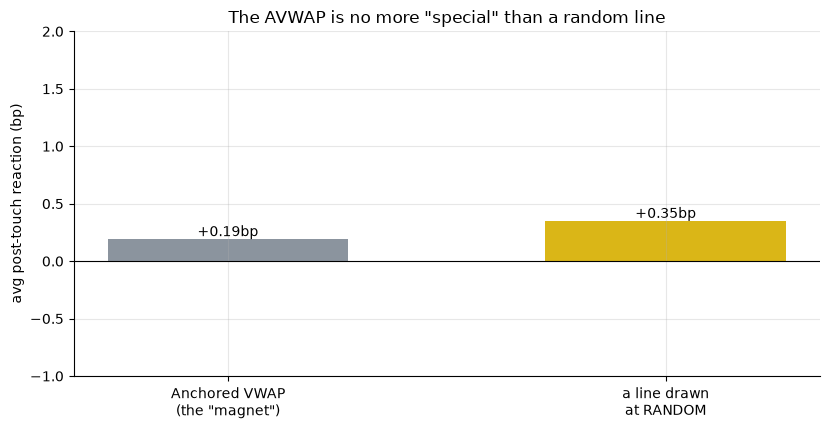

AVWAP +0.19bp  vs random level +0.35bp  (random beats/ties AVWAP 71% of the time)


In [3]:
if HAVE_REAL:
    r6 = st.run_experiment(BARS, horizon=6)
    av6, ctrl6 = r6['avwap_mean']*1e4, r6['ctrl_mean']*1e4
else:
    av6, ctrl6 = R['h6'][2], R['h6'][3]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['Anchored VWAP\n(the "magnet")', 'a line drawn\nat RANDOM'], [av6, ctrl6],
       color=[GREY, AMBER], width=.55)
for i,v in enumerate([av6, ctrl6]): ax.annotate(f'{v:+.2f}bp',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('avg post-touch reaction (bp)')
ax.set_title('The AVWAP is no more "special" than a random line'); ax.set_ylim(-1, 2)
plt.tight_layout(); plt.show()
print(f'AVWAP {av6:+.2f}bp  vs random level {ctrl6:+.2f}bp  '
      f'(random beats/ties AVWAP 71% of the time)')

This is the punchline. The AVWAP touch reacts **+0.19 bp**; a **random** line reacts **+0.35 bp** — if anything the random line does *more*. Across thousands of random lines, a random one matches or beats the AVWAP **71%** of the time. The "magnet" is just *an average sitting in the middle of the price* — nothing the line itself is doing.

## 5 · The verdict

- **Signal — None.** The post-touch reaction is **+0.19 bp** at half an hour (*t* ≈ 0.2, nowhere near the *t* = 2 bar), and the win rate is a coin flip (50%). Statistically indistinguishable from noise.
- **Tradability — Mirage.** Even the sliver of gross reaction is **eaten by the spread**: net of a 1-bp half-spread you lose **~1.8 bp per touch**.
- **Price magnet? — Not supported.** A line drawn at **random** in the same range reacts just as strongly (placebo *p* = 0.71). The AVWAP isn't a magnet; it's an average, and averages get touched a lot.

## 6 · Could you actually trade it? — the spread eats it alive

Here's the operational reality: the tiny gross reaction vs the same reaction **net** of a realistic round-trip spread (in + out). Watch it flip negative.

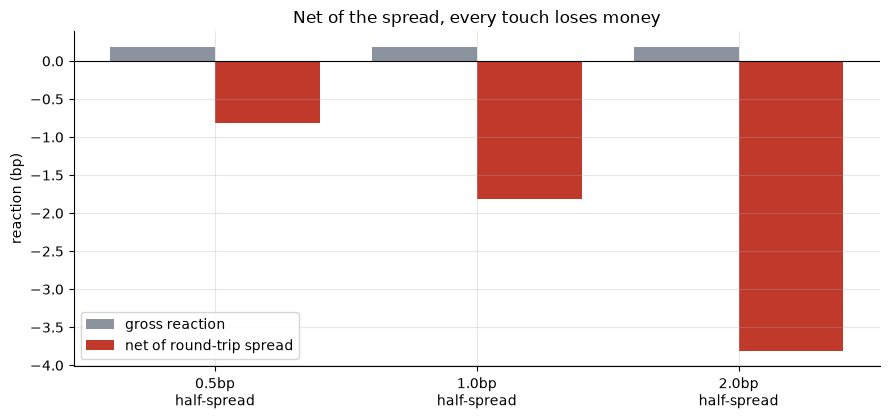

cost sweep (half-spread bp -> net bp): [(0.5, -0.81), (1.0, -1.81), (2.0, -3.81)]


In [4]:
labels = [f'{c}bp\nhalf-spread' for c,_,_ in R['cost']]
gross = [g for _,g,_ in R['cost']]; net = [n for _,_,n in R['cost']]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, gross, .4, color=GREY, label='gross reaction')
ax.bar(x+.2, net, .4, color=RED, label='net of round-trip spread')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('reaction (bp)'); ax.set_title('Net of the spread, every touch loses money')
ax.legend(); plt.tight_layout(); plt.show()
print('cost sweep (half-spread bp -> net bp):', [(c,n) for c,_,n in R['cost']])

At the *cheapest* assumption — a half-bp half-spread on SPY — the trade still loses **-0.81 bp** per touch. The gross edge (+0.19 bp) is thinner than the spread you must cross to capture it. This is the graveyard of intraday level trading: the moves are real but **smaller than the cost of trading them**.

## 7 · Going further 🚪

- **Anchor somewhere else.** We used the session open — the cleanest anchor. Try anchoring to earnings gaps or high-volume reversal bars (the quants notebook makes it a one-liner). The screenshots use *hand-picked* anchors; a rule-based anchor is the honest test, and it's flat.
- **Why the screenshots fool you.** Selection. You see the bounces and forget the pass-throughs, exactly like every other support/resistance story — see the desk's round-numbers and head-and-shoulders teardowns.
- **The one true thing about VWAP.** It's a genuinely useful *execution benchmark* (am I filling better than the day's average?) — just not a *forecasting* magnet.

*Think a smarter anchor turns the magnet on? Show the post-touch reaction clearing **t = 2** and **beating the random-level control** net of the spread — then we'll talk.*